<a href="https://colab.research.google.com/github/Rima6699/Amir-datmin/blob/main/2304020182_M_A_HUSAIN_PreProccessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [34]:
df = pd.read_csv("fifa_player_performance_market_value.csv")
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


## **Deskripsi Var:**
player_id: Nomor identitas unik untuk setiap pemain dalam dataset. Variabel ini hanya berfungsi sebagai penanda dan tidak digunakan dalam proses analisis atau pemodelan.

player_name: Nama pemain sepak bola. Variabel ini bersifat deskriptif dan tidak digunakan dalam proses pemodelan karena tidak memiliki nilai numerik.

age: Usia pemain dalam tahun yang digunakan untuk melihat pengaruh umur terhadap performa dan risiko transfer.

nationality: Negara asal pemain yang telah melalui proses encoding sehingga dapat digunakan dalam analisis model.

club: Klub tempat pemain bermain yang telah diubah ke dalam bentuk numerik melalui encoding.

position: Posisi bermain pemain (misalnya penyerang, gelandang, bek) yang telah dikonversi ke bentuk numerik.

goals: Jumlah gol yang dicetak oleh pemain sebagai indikator performa ofensif.

assists: Jumlah assist yang diberikan oleh pemain kepada rekan setim.

matches_played: Jumlah pertandingan yang dimainkan oleh pemain dalam satu periode tertentu.

minutes_played: Total menit bermain pemain dalam pertandingan, yang menunjukkan tingkat keterlibatan pemain.

yellow_cards: Jumlah kartu kuning yang diterima pemain sebagai indikator kedisiplinan.

red_cards: Jumlah kartu merah yang diterima pemain selama pertandingan.

injury_prone: Status apakah pemain rentan cedera atau tidak, yang telah diubah ke bentuk numerik melalui encoding.

market_value: Nilai pasar pemain yang menunjukkan estimasi harga pemain di bursa transfer.

transfer_risk_level: Variabel target yang menunjukkan tingkat risiko transfer pemain. Variabel ini telah diubah menjadi biner, yaitu 0 untuk risiko rendah dan 1 untuk risiko tinggi.

In [35]:
df['transfer_risk_level'].value_counts()

,count
transfer_risk_level,
Low,1250
Medium,991
High,559


In [36]:
df.describe()

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857
std,808.434702,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445
min,1.000000,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000
25%,700.750000,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000
50%,1400.500000,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000
75%,2100.250000,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000
max,2800.000000,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [38]:
#Mengubah multi-class menjadi binary
df['transfer_risk_level'] = np.where(df['transfer_risk_level'] > 0, 1, 0)

In [39]:
x = df.drop(columns=['player_id','player_name','transfer_risk_level'])
y = df['transfer_risk_level']

In [40]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

In [41]:
model = sm.Logit(y_train, sm.add_constant(x_train))
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.495656
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     transfer_risk_level   No. Observations:                 1960
Model:                           Logit   Df Residuals:                     1946
Method:                            MLE   Df Model:                           13
Date:                 Mon, 13 Apr 2026   Pseudo R-squ.:                0.003827
Time:                         15:15:05   Log-Likelihood:                -971.49
converged:                        True   LL-Null:                       -975.22
Covariance Type:             nonrobust   LLR p-value:                    0.8767
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.5399      0.753      0.717      0.474      -0.937       2.017
age                          0.0096      0.008      1.134      0.257      -0.007       0.026
nationality                 -0.0167      0.025     -0.670      0.503      -0.066       0.032
club                         0.0459      0.029      1.581      0.114      -0.011       0.103
position                    -0.0094      0.022     -0.430      0.667      -0.052       0.034
overall_rating               0.0026      0.006      0.446      0.656      -0.009       0.014
potential_rating             0.0019      0.006      0.331      0.741      -0.010       0.013
matches_played               0.0014      0.004      0.386      0.700      -0.006       0.008
goals                        0.0046      0.005      0.939      0.348      -0.005       0.014
assists                      0.0043      0.008      0.547      0.584      -0.011       0.020
minutes_played           -1.952e-05   4.42e-05     -0.442      0.658      -0.000     6.7e-05
market_value_million_eur     0.0011      0.001      0.986      0.324      -0.001       0.003
contract_years_left         -0.0080      0.033     -0.241      0.810      -0.073       0.057
injury_prone                -0.0405      0.132     -0.307      0.759      -0.299       0.218
============================================================================================
"""

In [54]:
#prediksilogit
pred = result.predict(sm.add_constant(x_test))
pred = np.where(pred <= 0.5, 0, 1)

accuracy_score(y_test, pred) * 100

79.64285714285714

In [51]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaling data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

pred = model.predict(x_test_scaled)

accuracy_score(y_test, pred) * 100

79.64285714285714

In [55]:
#KKN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

accuracy_score(y_test, y_pred) * 100

77.85714285714286

In [53]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

accuracy_score(y_test, y_pred) * 100

62.38095238095238

In [47]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

accuracy_score(y_test, y_pred) * 100

79.64285714285714

In [48]:
#support vector machine
from sklearn import svm

model = svm.SVC(kernel='linear')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred) * 100

79.64285714285714

## **Kesimpulan:**
Berdasarkan output Logistic Regression, KNN, Decision Tree, dan Support Vector Machine diperoleh akurasi sebagai berikut.

Logistic Regression: 79.64
KNN: 77.86
Decision Tree: 62.38
Support Vector Machine: 79.64

Dari keempat model tersebut, Logistic Regression dan Support Vector Machine memberikan akurasi tertinggi sebesar 79.64%, diikuti oleh KNN sebesar 77.86% dan Decision Tree sebesar 62.38%.

Dengan demikian, untuk kasus atau data yang digunakan dalam penelitian ini, model Logistic Regression dan Support Vector Machine dapat dianggap sebagai model terbaik berdasarkan kriteria akurasi. Hal ini menunjukkan bahwa pola hubungan antar variabel dalam dataset cenderung dapat dipisahkan secara linear.

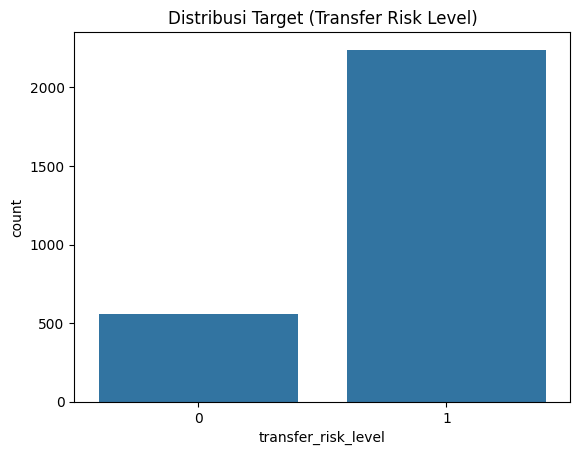

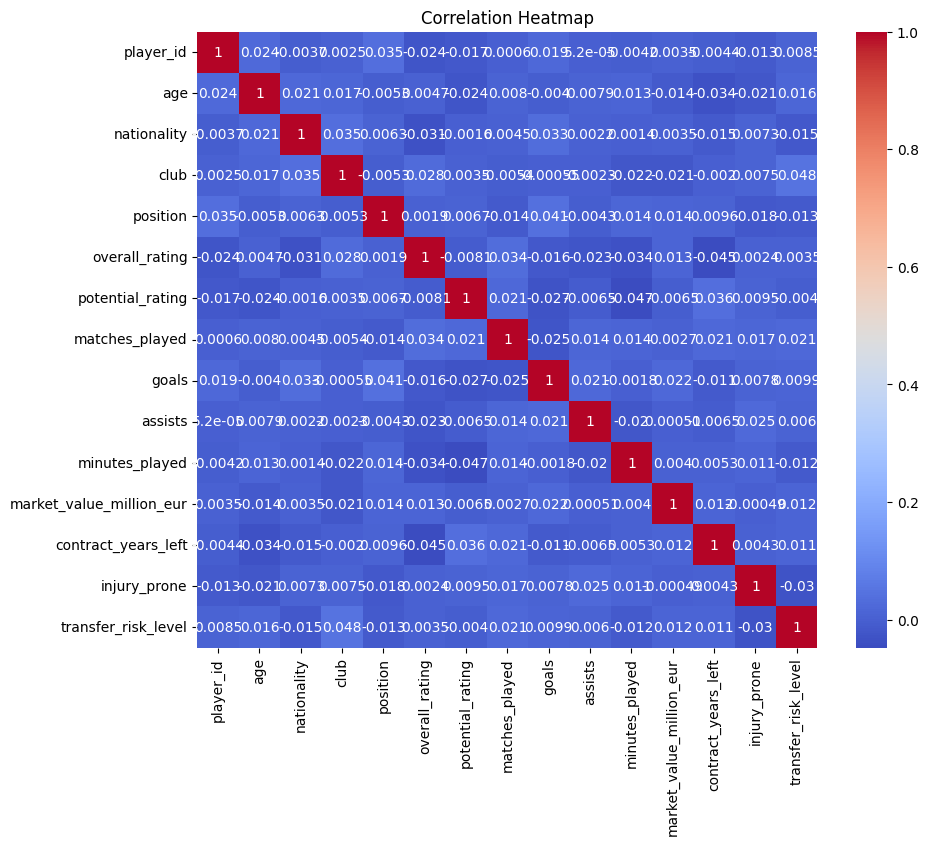

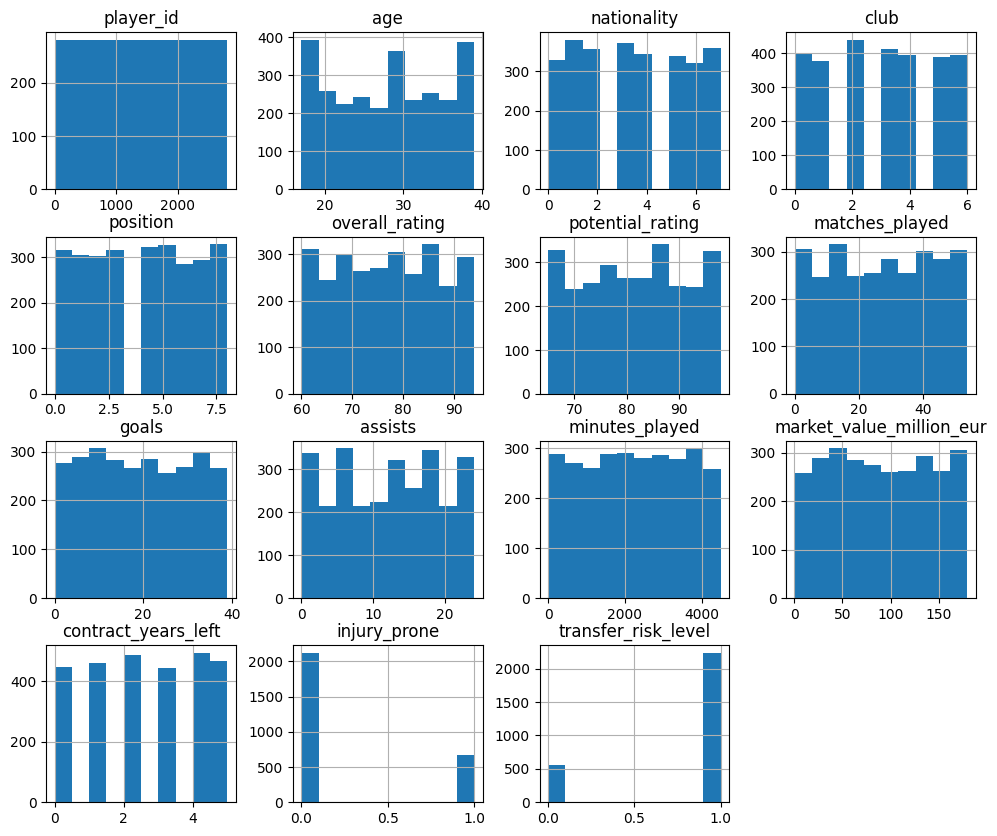

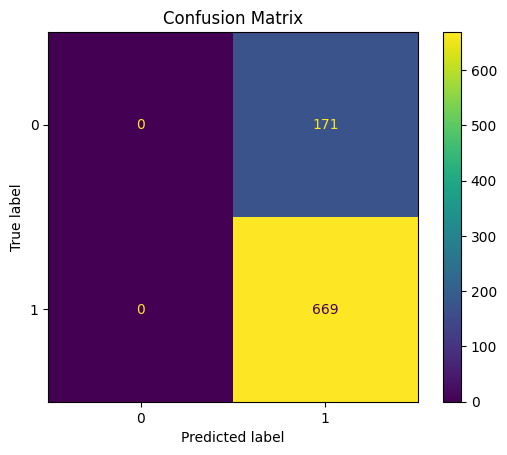

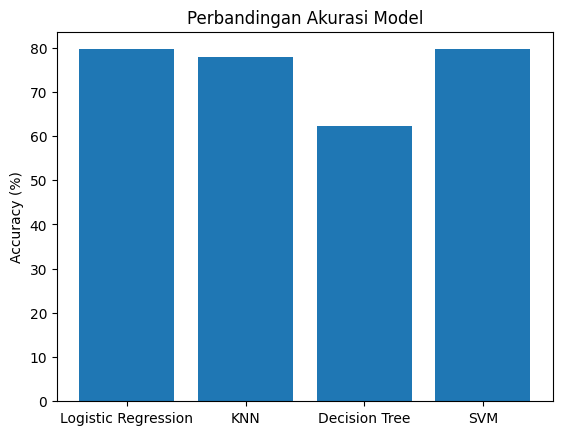

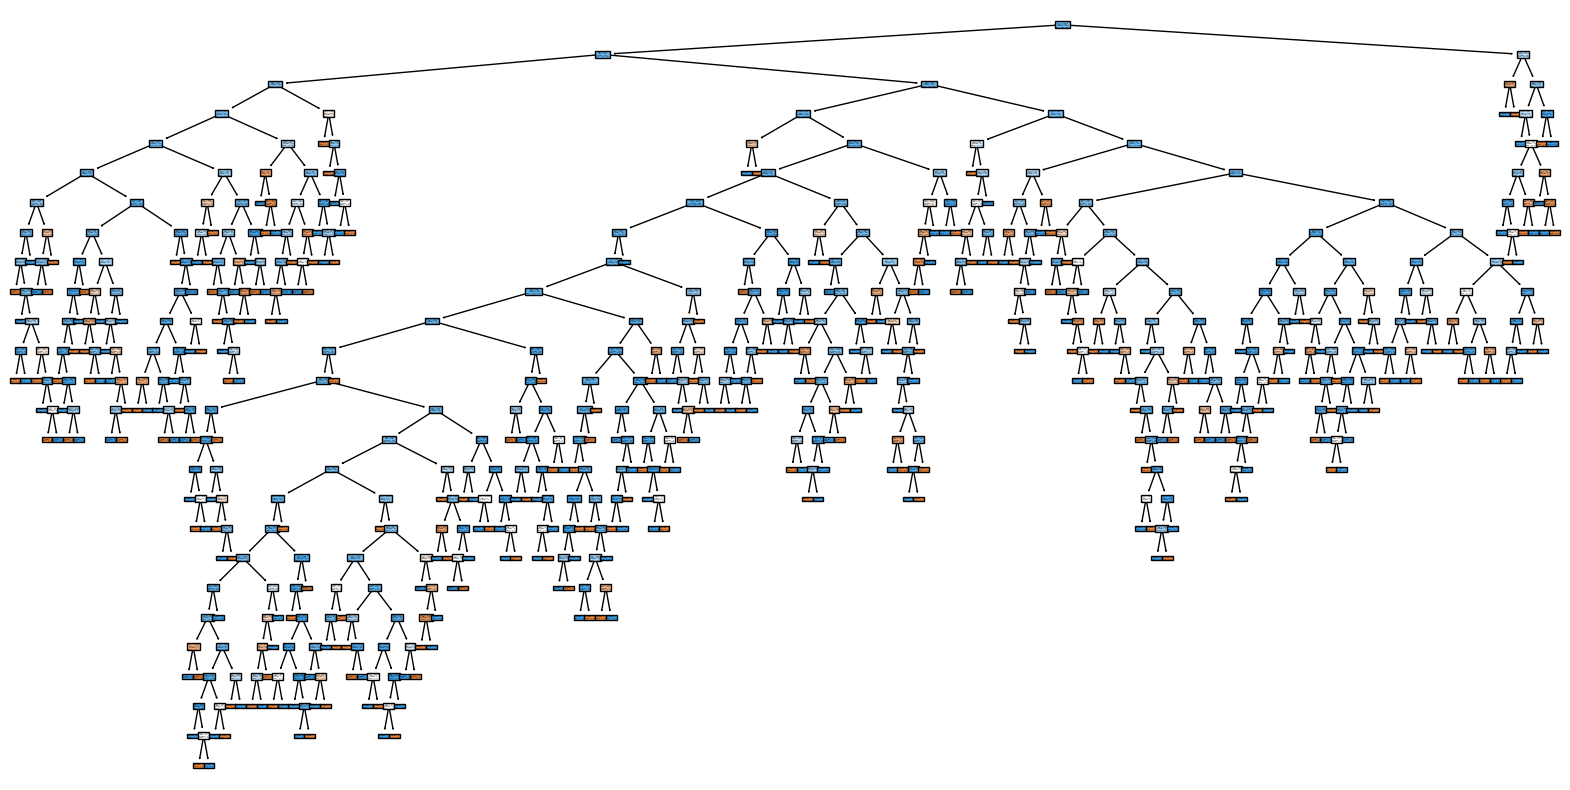

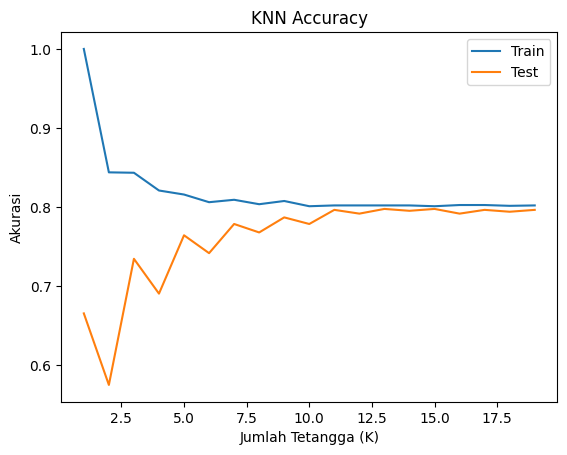

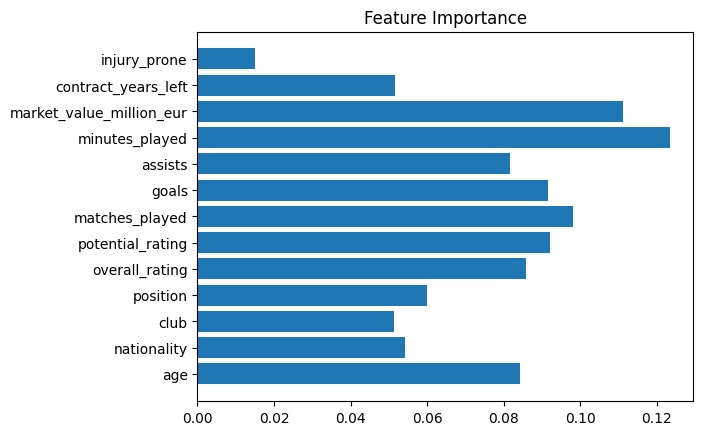

In [58]:
#VISUALISASI MODEL
sns.countplot(x='transfer_risk_level', data=df)
plt.title("Distribusi Target (Transfer Risk Level)")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
df.hist(figsize=(12,10))
plt.show()


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

model_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM']
accuracy = [79.64, 77.86, 62.38, 79.64]

plt.bar(model_names, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Perbandingan Akurasi Model")
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, filled=True)
plt.show()

neighbors = range(1, 20)
train_acc = []
test_acc = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)

    train_acc.append(knn.score(x_train, y_train))
    test_acc.append(knn.score(x_test, y_test))

plt.plot(neighbors, train_acc, label='Train')
plt.plot(neighbors, test_acc, label='Test')
plt.xlabel("Jumlah Tetangga (K)")
plt.ylabel("Akurasi")
plt.legend()
plt.title("KNN Accuracy")
plt.show()

importances = rf.feature_importances_

plt.barh(x.columns, importances)
plt.title("Feature Importance")
plt.show()

